In [3]:
print(1+1)

2


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
from matplotlib import animation, rc
from IPython.display import HTML
import csv
import math
import copy
import datetime
import time
from ipywidgets import Button, Output, VBox, HBox, Layout
from IPython.display import display
import ipywidgets as widgets
import matplotlib.animation as animation
from matplotlib.widgets import Button
from matplotlib.animation import FFMpegWriter

In [2]:
!pip install numpy matplotlib ipywidgets
!pip install ipympl

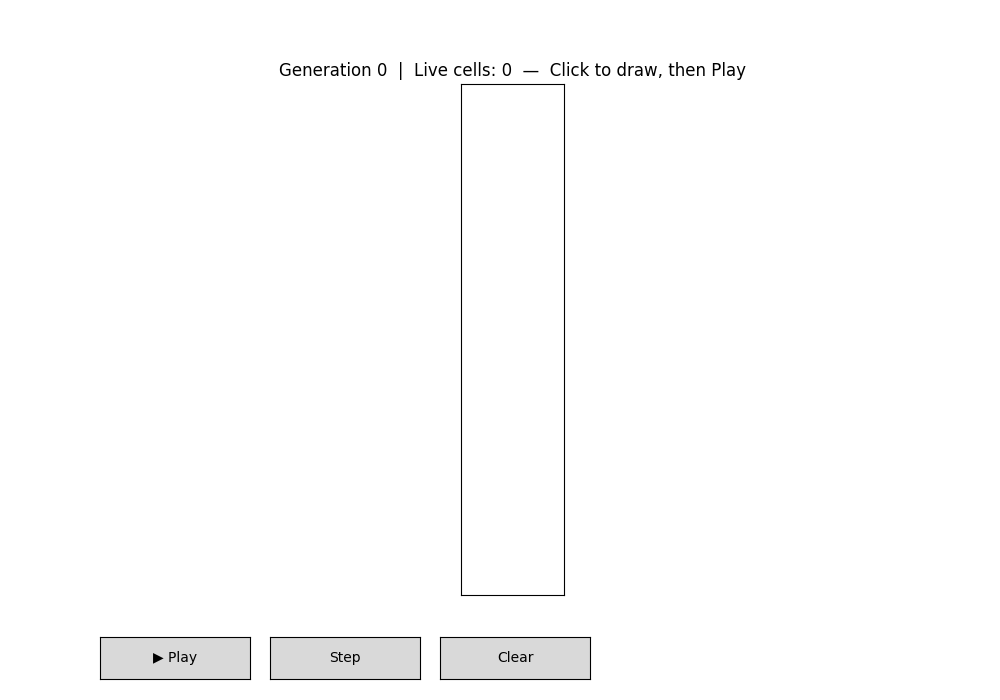

In [7]:
%matplotlib widget


ROWS, COLS = 200, 40

def next_generation(grid):
    neighbors = sum(
        np.roll(np.roll(grid, dr, axis=0), dc, axis=1)
        for dr in [-1, 0, 1] for dc in [-1, 0, 1]
        if (dr, dc) != (0, 0)
    )
    return ((neighbors == 3) | (grid & (neighbors == 2))).astype(int)

grid = np.zeros((ROWS, COLS), dtype=int)
running = False
generation = 0

fig, ax = plt.subplots(figsize=(10, 7))
plt.subplots_adjust(bottom=0.15)
img = ax.imshow(grid, cmap='binary', interpolation='nearest', vmin=0, vmax=1)
ax.set_xticks([])
ax.set_yticks([])
title = ax.set_title('Generation 0  |  Live cells: 0  —  Click to draw, then Play')

ax_play   = plt.axes([0.10, 0.03, 0.15, 0.06])
ax_step   = plt.axes([0.27, 0.03, 0.15, 0.06])
ax_clear  = plt.axes([0.44, 0.03, 0.15, 0.06])
#ax_random = plt.axes([0.61, 0.03, 0.15, 0.06])

btn_play   = Button(ax_play,   '▶ Play')
btn_step   = Button(ax_step,   'Step')
btn_clear  = Button(ax_clear,  'Clear')
#btn_random = Button(ax_random, 'Random')

def update_display():
    img.set_data(grid)
    title.set_text(f'Generation {generation}  |  Live cells: {grid.sum()}')
    fig.canvas.draw_idle()

def on_click(event):
    global grid
    if event.inaxes == ax and not running:
        c = int(round(event.xdata))
        r = int(round(event.ydata))
        if 0 <= r < ROWS and 0 <= c < COLS:
            grid[r, c] = 1 - grid[r, c]
            update_display()

fig.canvas.mpl_connect('button_press_event', on_click)

def animate(frame):
    global grid, generation
    if running:
        grid = next_generation(grid)
        generation += 1
        update_display()

ani = animation.FuncAnimation(fig, animate, interval=150, cache_frame_data=False)

def on_play(event):
    global running
    running = not running
    btn_play.label.set_text('⏸ Pause' if running else '▶ Play')
    fig.canvas.draw_idle()

def on_step(event):
    global grid, generation
    if not running:
        grid = next_generation(grid)
        generation += 1
        update_display()

def on_clear(event):
    global grid, generation, running
    running = False
    btn_play.label.set_text('▶ Play')
    grid = np.zeros((ROWS, COLS), dtype=int)
    generation = 0
    update_display()

def on_random(event):
    global grid, generation, running
    running = False
    btn_play.label.set_text('▶ Play')
    grid = np.random.choice([0, 1], size=(ROWS, COLS), p=[0.7, 0.3])
    generation = 0
    update_display()

btn_play.on_clicked(on_play)
btn_step.on_clicked(on_step)
btn_clear.on_clicked(on_clear)
#btn_random.on_clicked(on_random)

plt.show()



grid = np.zeros((ROWS, COLS), dtype=int)

# Stabilized switch engine (block-laying type) — Charles Corderman, 1971
# Runs indefinitely, leaves zig-zag trail of blocks diagonally
pattern = [
    ".OOO......O.....O......OOO.",
    "O..O.....OOO...OOO.....O..O",
    "...O....OO.O...O.OO....O...",
    "...O...................O....",
    "...O..O.............O..O...",
    "...O..OO...........OO..O...",
    "..O...OO...........OO...O..",
]

offset_r, offset_c = 5, 5
for r, row in enumerate(pattern):
    for c, ch in enumerate(row):
        if ch == 'O':
            grid[offset_r + r][offset_c + c] = 1

gun_cells = []  # not needed, pattern above handles it

In [10]:
print(1+1)

2
